In [1]:
import pandas as pd
import numpy as np 
# Station-level variables (census + premises)
census = pd.read_csv("station_independent_variables.csv")
premises = pd.read_csv("station_on_premises.csv")
station_vars = census.merge(premises, on=["station_id", "buffer_m"])

trips = pd.read_csv("glatrips.csv", parse_dates=["started_at"])

# Filter to chosen buffer
sv = station_vars[station_vars["buffer_m"] == 250].copy()

# OD-pair exposure (trip-weighted mean)
twm = pd.read_csv("glasgow_exposure_twm.csv")

static = pd.read_csv("glasgow_exposure_static.csv")[["origin", "destination", "route_len_m"]]
twm = twm.merge(static, on=["origin", "destination"], how="left")

# Merge origin-side station vars
reg = twm.merge(
    sv.add_prefix("o_").rename(columns={"o_station_id": "origin"}),
    on="origin", how="left"
)
# Merge destination-side station vars
reg = reg.merge(
    sv.add_prefix("d_").rename(columns={"d_station_id": "destination"}),
    on="destination", how="left"
)

In [2]:
origin_days = trips.groupby("origin")["started_at"].apply(
    lambda s: s.dt.date.nunique()
).rename("active_days")

dest_days = trips.groupby("destination")["started_at"].apply(
    lambda s: s.dt.date.nunique()
).rename("active_days")

# Combine (a station's active days = max of its origin and destination appearances)
active_days = pd.concat([origin_days, dest_days]).groupby(level=0).max()

reg = reg.merge(active_days.rename("o_active_days"), left_on="origin", right_index=True)
reg = reg.merge(active_days.rename("d_active_days"), left_on="destination", right_index=True)

# Joint active days = period both stations were live
reg["joint_active_days"] = reg[["o_active_days", "d_active_days"]].min(axis=1)

# Offset
reg["log_offset"] = np.log(reg["joint_active_days"])

In [3]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

# Log-transform mass and distance terms
reg["log_dist"] = np.log(reg["route_len_m"])
reg["log_o_pop"] = np.log1p(reg["o_over16pop"])
reg["log_d_pop"] = np.log1p(reg["d_over16pop"])
reg["log_d_workplace"] = np.log1p(reg["d_workplace_pop"])

# Define X columns
mass_cols = ["log_dist", "log_o_pop", "log_d_pop", "log_d_workplace"]
exposure_cols = ["exp_segregated", "exp_lane", "exp_shared"]
census_cols = ["o_avg_age", "d_avg_age",
               "o_avg_cars_per_household", "d_avg_cars_per_household",
               "o_student_share", "d_student_share", "o_avg_health_score",
               "d_avg_health_score", "o_avg_nssec_score", "d_avg_nssec_score",
               "o_cycling_distance_share_ext", "d_cycling_distance_share_ext"]
premises_cols = ["d_n_on_premises"]
X_cols = mass_cols + exposure_cols + census_cols + premises_cols
reg = reg.replace([np.inf, -np.inf], np.nan).dropna(subset=X_cols + ["log_offset"])
X = sm.add_constant(reg[X_cols].astype(float))
y = reg["trips"].astype(float)
offset = reg["log_offset"]

# Poisson first (baseline)
poisson = sm.GLM(y, X, family=sm.families.Poisson(), offset=offset).fit()
print(poisson.summary())

# Overdispersion test
resid_p = poisson.resid_pearson
overdispersion = (resid_p**2).sum() / poisson.df_resid
print(f"Overdispersion ratio: {overdispersion:.2f}")  # >>1 means NB needed

# Negative binomial
nb = NegativeBinomial(y, X, offset=offset).fit(maxiter=200)
print(nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  trips   No. Observations:                11060
Model:                            GLM   Df Residuals:                    11039
Model Family:                 Poisson   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.8115e+05
Date:                Sun, 16 Aug 2026   Deviance:                   1.1060e+06
Time:                        09:25:49   Pearson chi2:                 1.58e+06
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 4.843327
         Iterations: 123
         Function evaluations: 135
         Gradient evaluations: 130
                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11039
Method:                           MLE   Df Model:                           20
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06006
Time:                        09:25:51   Log-Likelihood:                -53567.
converged:                       True   LL-Null:                       -56990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    "variable": X_cols,
    "VIF": [variance_inflation_factor(X.values, i+1) for i in range(len(X_cols))]
})
print(vif.sort_values("VIF", ascending=False))

                        variable        VIF
14            d_avg_health_score  20.470773
13            o_avg_health_score  19.646709
8                      d_avg_age   9.592892
7                      o_avg_age   9.352424
16             d_avg_nssec_score   7.913557
15             o_avg_nssec_score   7.763079
18  d_cycling_distance_share_ext   5.491325
10      d_avg_cars_per_household   5.062783
12               d_student_share   4.615778
11               o_student_share   4.614693
9       o_avg_cars_per_household   4.224751
17  o_cycling_distance_share_ext   3.984256
3                log_d_workplace   3.679559
19               d_n_on_premises   2.294804
2                      log_d_pop   1.659394
1                      log_o_pop   1.598503
0                       log_dist   1.444997
6                     exp_shared   1.143213
4                 exp_segregated   1.110889
5                       exp_lane   1.055268


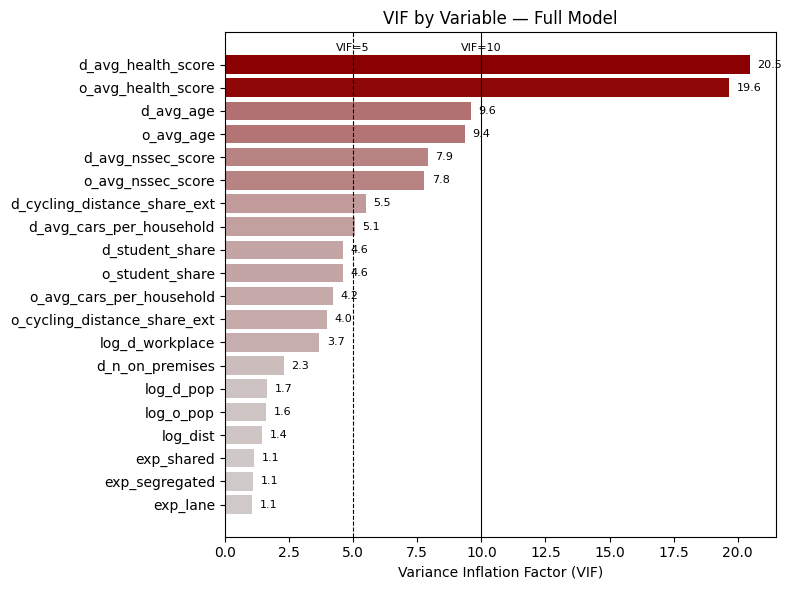

In [5]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

vif_sorted = vif.sort_values("VIF", ascending=True)

norm = mcolors.Normalize(vmin=0, vmax=vif_sorted["VIF"].max())
cmap = mcolors.LinearSegmentedColormap.from_list("grey_red", ["#d4d4d4", "#8b0000"])
colors = cmap(norm(vif_sorted["VIF"]))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(vif_sorted["variable"], vif_sorted["VIF"], color=colors)

# Conventional VIF thresholds
ax.axvline(5, color="black", linestyle="--", linewidth=0.8)
ax.axvline(10, color="black", linestyle="-", linewidth=0.8)
ax.text(5, len(vif_sorted)-0.5, "VIF=5", ha="center", va="bottom", fontsize=8)
ax.text(10, len(vif_sorted)-0.5, "VIF=10", ha="center", va="bottom", fontsize=8)

for bar, val in zip(bars, vif_sorted["VIF"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
            va="center", fontsize=8)

ax.set_xlabel("Variance Inflation Factor (VIF)")
ax.set_title("VIF by Variable — Full Model")
plt.tight_layout()
plt.savefig("vif_full_model.png", dpi=300)
plt.show()

In [6]:
# Drop only d_avg_health_score, keep o_avg_health_score, recheck VIF
X_cols_test = [c for c in X_cols if c != "d_avg_health_score"]
X_test = sm.add_constant(reg[X_cols_test].astype(float))

vif_test = pd.DataFrame({
    "variable": X_cols_test,
    "VIF": [variance_inflation_factor(X_test.values, i+1) for i in range(len(X_cols_test))]
})
print(vif_test.sort_values("VIF", ascending=False).head(5))

                        variable        VIF
13            o_avg_health_score  19.634978
7                      o_avg_age   9.343397
14             o_avg_nssec_score   7.757181
8                      d_avg_age   5.444277
17  d_cycling_distance_share_ext   5.051715


In [7]:
X_cols2 = [c for c in X_cols if "avg_health" not in c]
X2 = sm.add_constant(reg[X_cols2].astype(float))
nb2 = NegativeBinomial(y, X2, offset=offset).fit(maxiter=200)
print(nb2.summary())

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 4.843401
         Iterations: 98
         Function evaluations: 110
         Gradient evaluations: 105
                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11041
Method:                           MLE   Df Model:                           18
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06004
Time:                        09:25:55   Log-Likelihood:                -53568.
converged:                       True   LL-Null:                       -56990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------


In [8]:
vif = pd.DataFrame({
    "variable": X_cols2,
    "VIF": [variance_inflation_factor(X2.values, i+1) for i in range(len(X_cols2))]
})
print(vif.sort_values("VIF", ascending=False))

                        variable       VIF
8                      d_avg_age  5.442319
7                      o_avg_age  5.403639
16  d_cycling_distance_share_ext  5.051103
11               o_student_share  4.458528
12               d_student_share  4.439493
3                log_d_workplace  3.630898
10      d_avg_cars_per_household  3.218001
15  o_cycling_distance_share_ext  3.192466
9       o_avg_cars_per_household  2.810076
17               d_n_on_premises  2.248164
14             d_avg_nssec_score  2.133703
13             o_avg_nssec_score  1.834380
2                      log_d_pop  1.555082
1                      log_o_pop  1.519131
0                       log_dist  1.437915
6                     exp_shared  1.106832
4                 exp_segregated  1.104039
5                       exp_lane  1.054944


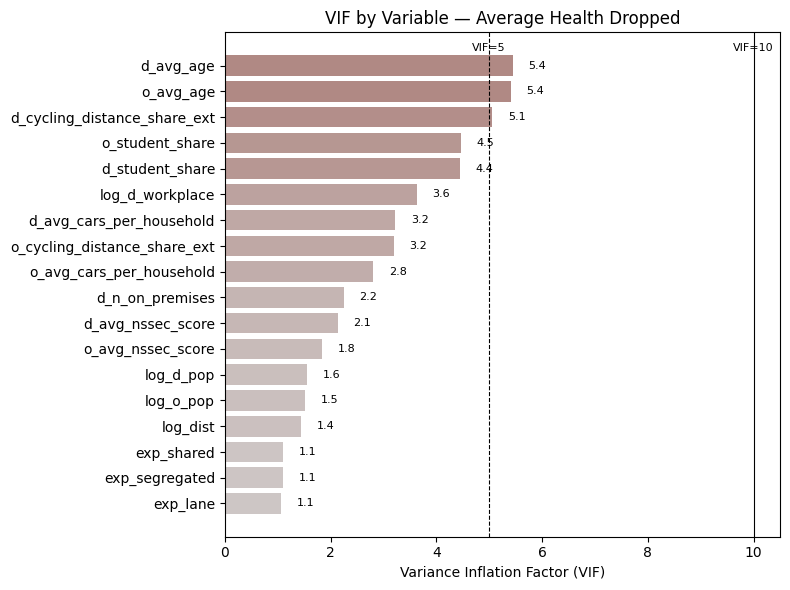

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

vif_sorted = vif.sort_values("VIF", ascending=True)

norm = mcolors.Normalize(vmin=0, vmax=vif_sorted["VIF"].max())
cmap = mcolors.LinearSegmentedColormap.from_list("grey_red", ["#d4d4d4", "#b08984"])
colors = cmap(norm(vif_sorted["VIF"]))

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(vif_sorted["variable"], vif_sorted["VIF"], color=colors)

# Conventional VIF thresholds
ax.axvline(5, color="black", linestyle="--", linewidth=0.8)
ax.axvline(10, color="black", linestyle="-", linewidth=0.8)
ax.text(5, len(vif_sorted)-0.5, "VIF=5", ha="center", va="bottom", fontsize=8)
ax.text(10, len(vif_sorted)-0.5, "VIF=10", ha="center", va="bottom", fontsize=8)

for bar, val in zip(bars, vif_sorted["VIF"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
            va="center", fontsize=8)

ax.set_xlabel("Variance Inflation Factor (VIF)")
ax.set_title("VIF by Variable — Average Health Dropped")
plt.tight_layout()
plt.savefig("vif_model2.png", dpi=300)
plt.show()

While d_student_share is significant, o_student_share is not therefore it is dropped due to reasons.

In [10]:
# Model 1: gravity only
m1_cols = ["log_dist", "log_o_pop", "log_d_pop", "log_d_workplace"]

# Model 2: + infrastructure exposure
m2_cols = m1_cols + ["exp_segregated", "exp_lane", "exp_shared"]

# Model 3: + census covariates
m3_cols = m2_cols + ["o_avg_age", "d_avg_age",
                     "o_avg_cars_per_household", "d_avg_cars_per_household"]

m4_cols = m3_cols + ["o_avg_nssec_score", "d_avg_nssec_score"]

m5_cols = m4_cols + ["o_cycling_distance_share_ext", "d_cycling_distance_share_ext", "d_student_share"]

m6_cols = m5_cols + ["d_n_on_premises"]

for i, cols in enumerate([m1_cols, m2_cols, m3_cols, m4_cols, m5_cols, m6_cols], 1):
    Xi = sm.add_constant(reg[cols].astype(float))
    nbi = NegativeBinomial(y, Xi, offset=offset).fit(maxiter=200, disp=0)
    print(f"\n=== Model {i}: {len(cols)} vars | AIC={nbi.aic:.0f} | LL={nbi.llf:.0f} ===")
    print(nbi.summary2().tables[1].to_string())


=== Model 1: 4 vars | AIC=108547 | LL=-54268 ===
                    Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
const            4.204186  0.272324  15.438160  9.064947e-54  3.670440  4.737932
log_dist        -1.399722  0.021361 -65.525643  0.000000e+00 -1.441590 -1.357854
log_o_pop        0.250476  0.015215  16.461953  6.884341e-61  0.220654  0.280297
log_d_pop        0.209151  0.014793  14.138434  2.201300e-45  0.180157  0.238144
log_d_workplace  0.122569  0.009491  12.914690  3.719370e-38  0.103967  0.141170
alpha            1.094629  0.013635  80.281489  0.000000e+00  1.067906  1.121353

=== Model 2: 7 vars | AIC=108378 | LL=-54180 ===
                    Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
const            3.470488  0.274263  12.653881  1.064824e-36  2.932943  4.008033
log_dist        -1.369640  0.021242 -64.478119  0.000000e+00 -1.411273 -1.328006
log_o_pop        0.274253  0.015062  18.208379  4.428699e-74  0.244732  0.303773
log_d_pop

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)



=== Model 3: 11 vars | AIC=108143 | LL=-54058 ===
                             Coef.  Std.Err.          z         P>|z|    [0.025    0.975]
const                     5.332707  0.348579  15.298427  7.832744e-53  4.649505  6.015909
log_dist                 -1.294665  0.021740 -59.550885  0.000000e+00 -1.337275 -1.252054
log_o_pop                 0.201513  0.016558  12.170299  4.474411e-34  0.169061  0.233966
log_d_pop                 0.199144  0.016897  11.785902  4.614536e-32  0.166027  0.232261
log_d_workplace           0.112085  0.012937   8.663834  4.561562e-18  0.086729  0.137442
exp_segregated            0.164795  0.066479   2.478896  1.317898e-02  0.034498  0.295092
exp_lane                  0.737587  0.209958   3.513027  4.430319e-04  0.326078  1.149097
exp_shared                0.571993  0.072972   7.838522  4.558820e-15  0.428970  0.715016
o_avg_age                -0.033639  0.002661 -12.639191  1.283686e-36 -0.038855 -0.028422
d_avg_age                -0.025407  0.002896  -8.

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)



=== Model 4: 13 vars | AIC=107561 | LL=-53766 ===
                             Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
const                     8.633406  0.371929  23.212486  3.406033e-119  7.904437  9.362374
log_dist                 -1.281234  0.021158 -60.554594   0.000000e+00 -1.322704 -1.239765
log_o_pop                 0.145066  0.016605   8.736422   2.406098e-18  0.112521  0.177610
log_d_pop                 0.123111  0.017311   7.111804   1.145359e-12  0.089182  0.157039
log_d_workplace           0.057535  0.012880   4.467053   7.930456e-06  0.032291  0.082779
exp_segregated            0.274768  0.066035   4.160937   3.169449e-05  0.145342  0.404195
exp_lane                  0.031739  0.205535   0.154424   8.772757e-01 -0.371102  0.434581
exp_shared                0.433517  0.070533   6.146329   7.929649e-10  0.295276  0.571759
o_avg_age                -0.007420  0.002978  -2.492004   1.270247e-02 -0.013256 -0.001584
d_avg_age                -0.005929  0.0

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)



=== Model 5: 16 vars | AIC=107181 | LL=-53573 ===
                                 Coef.  Std.Err.          z          P>|z|    [0.025     0.975]
const                         9.301589  0.412294  22.560571  1.057493e-112  8.493508  10.109671
log_dist                     -1.353172  0.021593 -62.668233   0.000000e+00 -1.395493  -1.310851
log_o_pop                     0.058949  0.018950   3.110809   1.865753e-03  0.021808   0.096090
log_d_pop                     0.023520  0.018817   1.249919   2.113290e-01 -0.013361   0.060402
log_d_workplace               0.198441  0.015356  12.922424   3.363756e-38  0.168343   0.228539
exp_segregated                0.336539  0.067267   5.003030   5.643606e-07  0.204698   0.468380
exp_lane                     -0.136928  0.203041  -0.674386   5.000660e-01 -0.534881   0.261025
exp_shared                    0.318949  0.069754   4.572464   4.820230e-06  0.182233   0.455665
o_avg_age                    -0.021037  0.003243  -6.487097   8.750615e-11 -0.027393 

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)



=== Model 6: 17 vars | AIC=107174 | LL=-53568 ===
                                 Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
const                         9.171999  0.414068  22.150962  1.021148e-108  8.360441  9.983557
log_dist                     -1.355726  0.021607 -62.744958   0.000000e+00 -1.398074 -1.313377
log_o_pop                     0.060619  0.018946   3.199567   1.376344e-03  0.023485  0.097752
log_d_pop                     0.028446  0.018908   1.504448   1.324659e-01 -0.008613  0.065504
log_d_workplace               0.186757  0.015824  11.802232   3.800924e-32  0.155743  0.217771
exp_segregated                0.332451  0.067217   4.945906   7.579045e-07  0.200707  0.464194
exp_lane                     -0.115592  0.202948  -0.569564   5.689736e-01 -0.513362  0.282179
exp_shared                    0.352714  0.070616   4.994821   5.889032e-07  0.214309  0.491119
o_avg_age                    -0.020849  0.003242  -6.430655   1.270556e-10 -0.027204 -0.014495

In [11]:
mass_cols = ["log_dist", "log_o_pop", "log_d_pop", "log_d_workplace"]
exposure_cols = ["exp_segregated", "exp_lane", "exp_shared"]
census_cols = ["o_avg_age", "d_avg_age",
               "o_avg_cars_per_household", "d_avg_cars_per_household",
               "d_student_share", "o_avg_nssec_score", "d_avg_nssec_score",
               "o_cycling_distance_share_ext", "d_cycling_distance_share_ext"]
premises_cols = ["d_n_on_premises"]
X_cols3 = mass_cols + exposure_cols + census_cols + premises_cols
reg = reg.replace([np.inf, -np.inf], np.nan).dropna(subset=X_cols3 + ["log_offset"])
X3 = sm.add_constant(reg[X_cols3].astype(float))
y = reg["trips"].astype(float)
offset = reg["log_offset"]

nb3 = NegativeBinomial(y, X3, offset=offset).fit(maxiter=200)
print(nb3.summary())

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


Optimization terminated successfully.
         Current function value: 4.843401
         Iterations: 90
         Function evaluations: 102
         Gradient evaluations: 97
                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11042
Method:                           MLE   Df Model:                           17
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06004
Time:                        09:26:02   Log-Likelihood:                -53568.
converged:                       True   LL-Null:                       -56990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
c

In [12]:
commuter = pd.read_csv("precovidcommuter_labels.csv")[["origin_c", "dest_c", "is_commuter"]]

# Your TWM uses origin/destination — need to create canonical keys to match
reg["origin_c"] = reg[["origin", "destination"]].apply(
    lambda r: tuple(sorted([r["origin"], r["destination"]]))[0], axis=1)
reg["dest_c"] = reg[["origin", "destination"]].apply(
    lambda r: tuple(sorted([r["origin"], r["destination"]]))[1], axis=1)

reg = reg.merge(commuter, on=["origin_c", "dest_c"], how="left")
reg["is_commuter"] = reg["is_commuter"].fillna(False).astype(int)


y = reg["trips"].astype(float)
offset = reg["log_offset"]

# Refit with interactions
X_cols4 = X_cols3 + ["is_commuter"]
X4 = sm.add_constant(reg[X_cols4].astype(float))
nb4 = NegativeBinomial(y, X4, offset=offset).fit(maxiter=200, disp=0)
print(nb4.summary())

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11041
Method:                           MLE   Df Model:                           18
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06364
Time:                        09:26:04   Log-Likelihood:                -53363.
converged:                       True   LL-Null:                       -56990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            8.3477      0.410     20.379      0.000       7.545       9.151
log_dist                        -1.3497      0.021    -63.799      0.000     

In [13]:
reg["commuter_x_segregated"] = reg["is_commuter"] * reg["exp_segregated"]
reg["commuter_x_shared"] = reg["is_commuter"] * reg["exp_shared"]

X_cols5 = X_cols4 + ["commuter_x_segregated", "commuter_x_shared"]
X5 = sm.add_constant(reg[X_cols5].astype(float))
nb5 = NegativeBinomial(y, X5, offset=offset).fit(maxiter=200, disp=0)
print(nb5.summary())

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11039
Method:                           MLE   Df Model:                           20
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06380
Time:                        09:26:05   Log-Likelihood:                -53354.
converged:                       True   LL-Null:                       -56990.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            8.3470      0.409     20.401      0.000       7.545       9.149
log_dist                        -1.3520      0.021    -63.856      0.000     

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discre

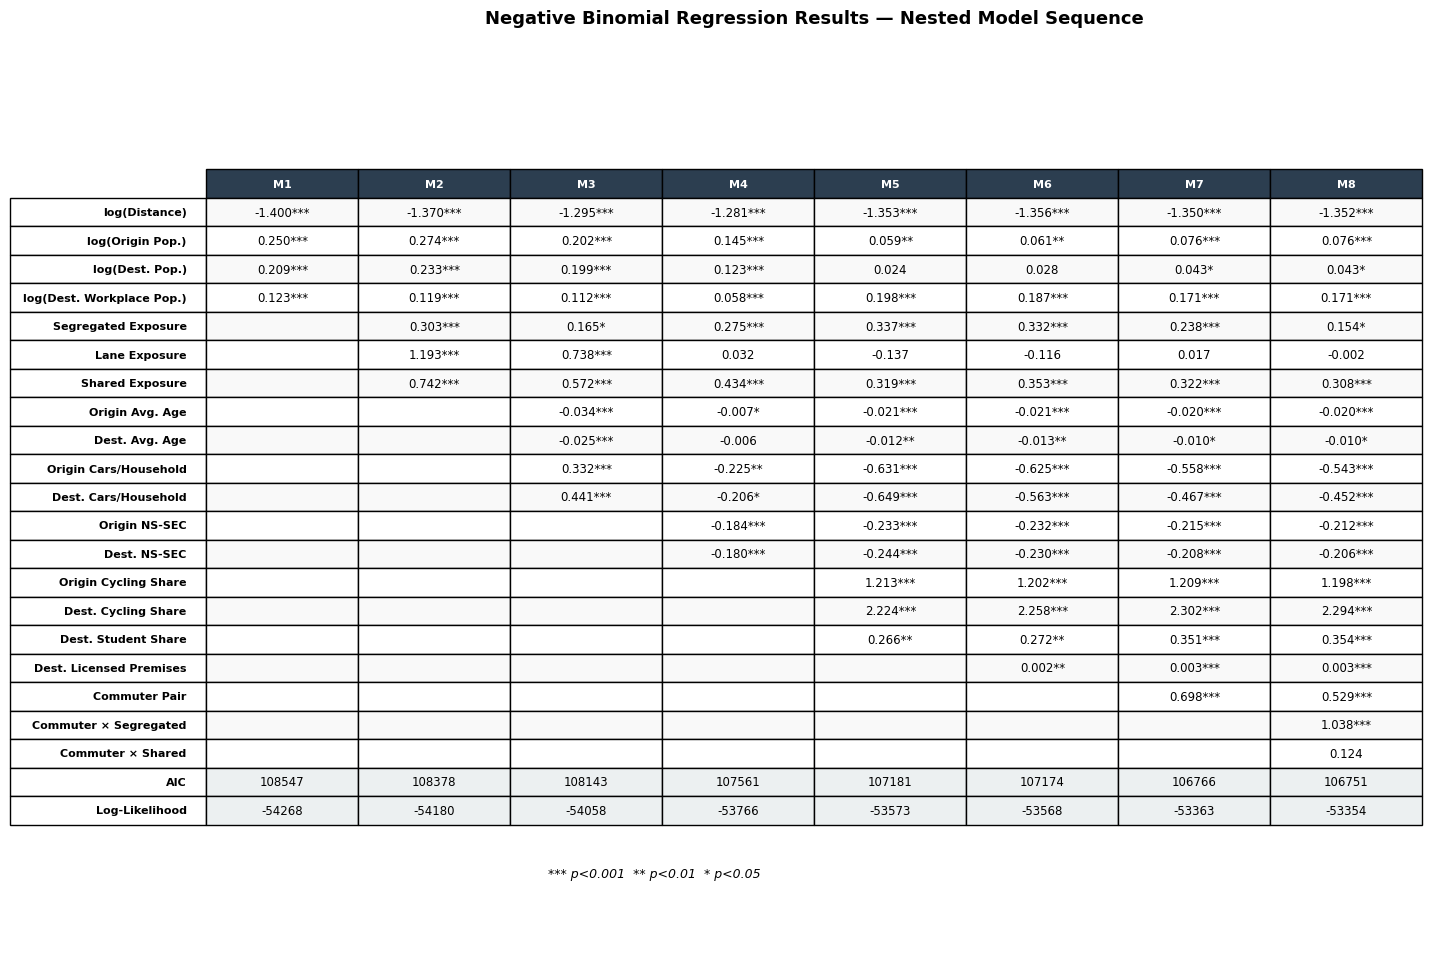

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Re-run all models and store results ----
from collections import OrderedDict

model_specs = OrderedDict({
    "M1": ["log_dist", "log_o_pop", "log_d_pop", "log_d_workplace"],
})
model_specs["M2"] = model_specs["M1"] + ["exp_segregated", "exp_lane", "exp_shared"]
model_specs["M3"] = model_specs["M2"] + ["o_avg_age", "d_avg_age",
    "o_avg_cars_per_household", "d_avg_cars_per_household"]
model_specs["M4"] = model_specs["M3"] + ["o_avg_nssec_score", "d_avg_nssec_score"]
model_specs["M5"] = model_specs["M4"] + [
    "o_cycling_distance_share_ext", "d_cycling_distance_share_ext", "d_student_share"]
model_specs["M6"] = model_specs["M5"] + ["d_n_on_premises"]
model_specs["M7"] = model_specs["M6"] + ["is_commuter"]
model_specs["M8"] = model_specs["M7"] + ["commuter_x_segregated", "commuter_x_shared"]

results = {}
for name, cols in model_specs.items():
    Xi = sm.add_constant(reg[cols].astype(float))
    nbi = NegativeBinomial(y, Xi, offset=offset).fit(maxiter=200, disp=0)
    results[name] = nbi

# ---- Build the table ----
all_vars = list(model_specs[list(model_specs.keys())[-1]])  # full variable list from final model
display_names = {
    "log_dist": "log(Distance)",
    "log_o_pop": "log(Origin Pop.)",
    "log_d_pop": "log(Dest. Pop.)",
    "log_d_workplace": "log(Dest. Workplace Pop.)",
    "exp_segregated": "Segregated Exposure",
    "exp_lane": "Lane Exposure",
    "exp_shared": "Shared Exposure",
    "o_avg_age": "Origin Avg. Age",
    "d_avg_age": "Dest. Avg. Age",
    "o_avg_cars_per_household": "Origin Cars/Household",
    "d_avg_cars_per_household": "Dest. Cars/Household",
    "o_avg_nssec_score": "Origin NS-SEC",
    "d_avg_nssec_score": "Dest. NS-SEC",
    "o_cycling_distance_share_ext": "Origin Cycling Share",
    "d_cycling_distance_share_ext": "Dest. Cycling Share",
    "d_student_share": "Dest. Student Share",
    "d_n_on_premises": "Dest. Licensed Premises",
    "is_commuter": "Commuter Pair",
    "commuter_x_segregated": "Commuter × Segregated",
    "commuter_x_shared": "Commuter × Shared",
}

def stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

model_names = list(results.keys())
n_models = len(model_names)
n_vars = len(all_vars)

# Build cell text
cell_text = []
for var in all_vars:
    row = []
    for mname in model_names:
        res = results[mname]
        if var in res.params.index:
            coef = res.params[var]
            p = res.pvalues[var]
            row.append(f"{coef:.3f}{stars(p)}")
        else:
            row.append("")
    cell_text.append(row)

# Add AIC and LL rows
aic_row = [f"{results[m].aic:.0f}" for m in model_names]
ll_row = [f"{results[m].llf:.0f}" for m in model_names]
cell_text.append(aic_row)
cell_text.append(ll_row)

row_labels = [display_names.get(v, v) for v in all_vars] + ["AIC", "Log-Likelihood"]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=model_names,
    cellLoc='center',
    rowLoc='right',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.4)

# Style header row
for j in range(n_models):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=8)

# Style row labels
for i in range(len(row_labels)):
    table[i+1, -1].set_text_props(fontweight='bold', fontsize=8)

# Shade AIC/LL rows
for j in range(n_models):
    table[len(all_vars)+1, j].set_facecolor('#ecf0f1')
    table[len(all_vars)+2, j].set_facecolor('#ecf0f1')

# Alternate row shading
for i in range(len(all_vars)):
    for j in range(n_models):
        if i % 2 == 0:
            table[i+1, j].set_facecolor('#f9f9f9')

plt.title("Negative Binomial Regression Results — Nested Model Sequence",
          fontsize=13, fontweight='bold', pad=1)
plt.figtext(0.5, 0.1, "*** p<0.001  ** p<0.01  * p<0.05", ha='center', fontsize=9, style='italic')
plt.subplots_adjust(left=0.22, right=0.98, top=0.95, bottom=0.01)
plt.savefig('nb_model_table.png', dpi=250, bbox_inches='tight')
plt.show()

In [15]:
from scipy import stats

# nb_main = baseline + is_commuter only
# nb_interact = baseline + is_commuter + interactions
LR_stat = 2 * (nb5.llf - nb4.llf)
df_diff = nb5.df_model - nb4.df_model
p_value = stats.chi2.sf(LR_stat, df_diff)
print(f"LR = {LR_stat:.2f}, df = {df_diff}, p = {p_value:.4g}")

LR = 18.88, df = 2.0, p = 7.947e-05


In [16]:
reg["predicted"] = nb5.predict(X5, offset=offset)
print(f"Pearson r: {reg['predicted'].corr(reg['trips']):.3f}")

Pearson r: 0.433


## **Negative Bionomial Robustness Check**

In [18]:
groups = reg.loc[X5.index, "origin"].astype("category").cat.codes.values
assert len(groups) == X5.shape[0]

nb5_cl = NegativeBinomial(y, X5, offset=offset).fit(
       maxiter=200, disp=0, cov_type="cluster",
       cov_kwds={"groups": reg["origin"].astype("category").cat.codes})

print(nb5_cl.mle_retvals["converged"])
print(nb5_cl.summary())
print((nb5_cl.params - nb5.params).abs().max()) 

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


True
                     NegativeBinomial Regression Results                      
Dep. Variable:                  trips   No. Observations:                11060
Model:               NegativeBinomial   Df Residuals:                    11039
Method:                           MLE   Df Model:                           20
Date:                Sun, 16 Aug 2026   Pseudo R-squ.:                 0.06380
Time:                        09:26:13   Log-Likelihood:                -53354.
converged:                       True   LL-Null:                       -56990.
Covariance Type:              cluster   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            8.3470      0.911      9.164      0.000       6.562      10.132
log_dist                        -1.3520      0.051    -26.337      0.000

In [19]:
import pandas as pd
cmp = pd.DataFrame({
    "coef":       nb5.params,
    "se_naive":   nb5.bse,
    "se_cluster": nb5_cl.bse,
    "p_naive":    nb5.pvalues,
    "p_cluster":  nb5_cl.pvalues,
})
cmp["se_ratio"] = cmp.se_cluster / cmp.se_naive
print(cmp.round(4).to_string())

                                coef  se_naive  se_cluster  p_naive  p_cluster  se_ratio
const                         8.3470    0.4091      0.9109   0.0000     0.0000    2.2263
log_dist                     -1.3520    0.0212      0.0513   0.0000     0.0000    2.4245
log_o_pop                     0.0757    0.0186      0.0716   0.0000     0.2900    3.8415
log_d_pop                     0.0433    0.0187      0.0231   0.0205     0.0616    1.2392
log_d_workplace               0.1712    0.0156      0.0180   0.0000     0.0000    1.1514
exp_segregated                0.1542    0.0684      0.1670   0.0241     0.3560    2.4429
exp_lane                     -0.0019    0.2003      0.3524   0.9923     0.9956    1.7593
exp_shared                    0.3084    0.0733      0.1537   0.0000     0.0448    2.0983
o_avg_age                    -0.0201    0.0032      0.0139   0.0000     0.1464    4.3349
d_avg_age                    -0.0099    0.0043      0.0060   0.0206     0.1009    1.4112
o_avg_cars_per_househ

In [20]:
import numpy as np, pandas as pd
from scipy import stats

m  = NegativeBinomial(y, X5, offset=offset)
go = reg.loc[X5.index, "origin"].astype("category").cat.codes.values
gd = reg.loc[X5.index, "destination"].astype("category").cat.codes.values
gp = np.arange(len(X5))          # each row its own cluster == robust sandwich

r_o = m.fit(maxiter=200, disp=0, cov_type="cluster", cov_kwds={"groups": go})
r_d = m.fit(maxiter=200, disp=0, cov_type="cluster", cov_kwds={"groups": gd})
r_p = m.fit(maxiter=200, disp=0, cov_type="cluster", cov_kwds={"groups": gp})

# Cameron-Gelbach-Miller: V_two-way = V_origin + V_dest - V_intersection
V2 = r_o.cov_params().values + r_d.cov_params().values - r_p.cov_params().values
d2 = np.diag(V2)
print("negative variances:", (d2 < 0).sum())     # must be 0

se2 = np.sqrt(np.clip(d2, 0, None))
z2  = r_o.params.values / se2
out = pd.DataFrame({
    "coef": r_o.params.values,
    "se_2way": se2,
    "z": z2,
    "p": 2 * stats.norm.sf(np.abs(z2)),
}, index=r_o.params.index)
print(out.round(4).to_string())

print("clusters:", len(np.unique(go)), "origins,", len(np.unique(gd)), "destinations")

C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\discrete\discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


negative variances: 0
                                coef  se_2way        z       p
const                         8.3470   1.7116   4.8766  0.0000
log_dist                     -1.3520   0.0661 -20.4400  0.0000
log_o_pop                     0.0757   0.0731   1.0361  0.3001
log_d_pop                     0.0433   0.0882   0.4904  0.6239
log_d_workplace               0.1712   0.0693   2.4693  0.0135
exp_segregated                0.1542   0.2092   0.7370  0.4611
exp_lane                     -0.0019   0.5088  -0.0038  0.9970
exp_shared                    0.3084   0.1895   1.6279  0.1036
o_avg_age                    -0.0201   0.0138  -1.4592  0.1445
d_avg_age                    -0.0099   0.0158  -0.6232  0.5332
o_avg_cars_per_household     -0.5431   0.2743  -1.9795  0.0478
d_avg_cars_per_household     -0.4525   0.3007  -1.5049  0.1323
d_student_share               0.3541   0.4325   0.8187  0.4129
o_avg_nssec_score            -0.2120   0.0386  -5.4898  0.0000
d_avg_nssec_score            -0.2

In [21]:
print("negative variances:", (np.diag(V2) < 0).sum())
print("clusters:", len(np.unique(go)), "origins,", len(np.unique(gd)), "destinations")

negative variances: 0
clusters: 120 origins, 120 destinations


In [22]:
names = list(r_o.params.index)
c = np.zeros(len(names))
c[names.index("exp_segregated")] = 1
c[names.index("commuter_x_segregated")] = 1
est = float(c @ r_o.params.values)
se  = float(np.sqrt(c @ V2 @ c))
print(f"IRR {np.exp(est):.3f}  95% CI [{np.exp(est-1.96*se):.3f}, {np.exp(est+1.96*se):.3f}]"
      f"  p={2*stats.norm.sf(abs(est/se)):.2g}")

IRR 3.296  95% CI [1.989, 5.460]  p=3.6e-06


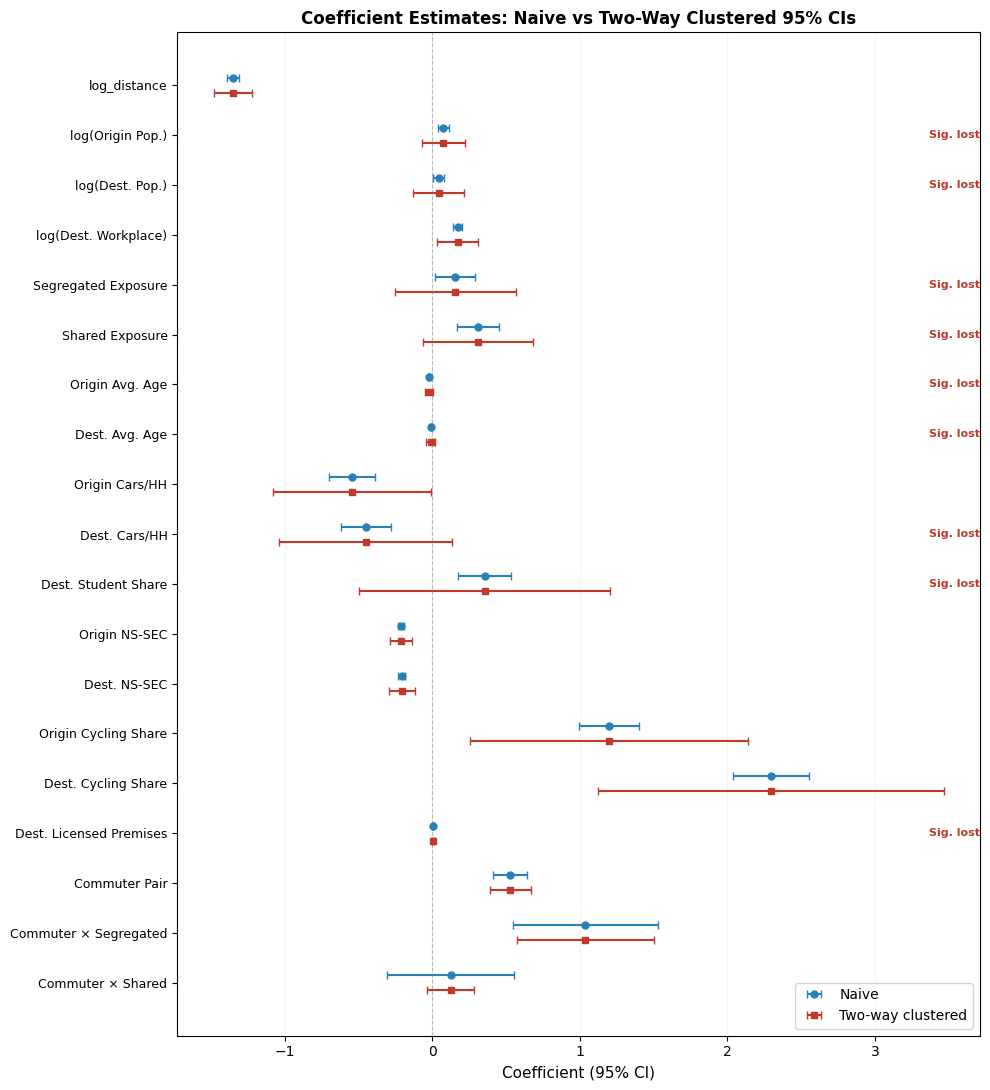

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

data = {
    "log_distance":             {"coef": -1.3520, "se_naive": 0.0210, "se_cluster":0.0661},
    "log(Origin Pop.)":         {"coef": 0.0757,  "se_naive": 0.0186, "se_cluster": 0.0731},
    "log(Dest. Pop.)":          {"coef": 0.0433,  "se_naive": 0.0187, "se_cluster": 0.0882},
    "log(Dest. Workplace)":     {"coef": 0.1712,  "se_naive": 0.0156, "se_cluster": 0.0693},
    "Segregated Exposure":      {"coef": 0.1542,  "se_naive": 0.0684, "se_cluster": 0.2092},
    "Shared Exposure":          {"coef": 0.3084,  "se_naive": 0.0733, "se_cluster": 0.1895},
    "Origin Avg. Age":          {"coef": -0.0201, "se_naive": 0.0032, "se_cluster": 0.0138},
    "Dest. Avg. Age":           {"coef": -0.0099, "se_naive": 0.0043, "se_cluster": 0.0158},
    "Origin Cars/HH":           {"coef": -0.5431, "se_naive": 0.0800, "se_cluster": 0.2743},
    "Dest. Cars/HH":            {"coef": -0.4525, "se_naive": 0.0864, "se_cluster": 0.3007},
    "Dest. Student Share":      {"coef": 0.3541,  "se_naive": 0.0914, "se_cluster": 0.4325},
    "Origin NS-SEC":            {"coef": -0.2120, "se_naive": 0.0111, "se_cluster": 0.0386},
    "Dest. NS-SEC":             {"coef": -0.2055, "se_naive": 0.0120, "se_cluster": 0.0457},
    "Origin Cycling Share":     {"coef": 1.1977,  "se_naive": 0.1026, "se_cluster": 0.4813},
    "Dest. Cycling Share":      {"coef": 2.2937,  "se_naive": 0.1314, "se_cluster": 0.5978},
    "Dest. Licensed Premises":  {"coef": 0.0031,  "se_naive": 0.0007, "se_cluster": 0.0028},
    "Commuter Pair":            {"coef": 0.5286,  "se_naive": 0.0584, "se_cluster": 0.0717},
    "Commuter × Segregated":    {"coef": 1.0384,  "se_naive": 0.2505, "se_cluster": 0.2359},
    "Commuter × Shared":        {"coef": 0.1240,  "se_naive": 0.2182, "se_cluster": 0.0812},
}

vars_plot = list(data.keys())
fig, ax = plt.subplots(figsize=(10, 11))

y_positions = np.arange(len(vars_plot))[::-1]
offset = 0.15

for i, var in enumerate(vars_plot):
    d = data[var]
    y = y_positions[i]
    coef = d["coef"]
    ci_naive = 1.96 * d["se_naive"]
    ci_cluster = 1.96 * d["se_cluster"]

    ax.errorbar(coef, y + offset, xerr=ci_naive, fmt='o', color='#2980b9',
                markersize=5, capsize=3, linewidth=1.5, label='Naive' if i == 0 else None)
    ax.errorbar(coef, y - offset, xerr=ci_cluster, fmt='s', color='#c0392b',
                markersize=5, capsize=3, linewidth=1.5, label='Two-way clustered' if i == 0 else None)

ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_yticks(y_positions)
ax.set_yticklabels(vars_plot, fontsize=9)
ax.set_xlabel('Coefficient (95% CI)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='x', alpha=0.15)

for i, var in enumerate(vars_plot):
    d = data[var]
    y = y_positions[i]
    p_naive = 2 * stats.norm.sf(abs(d["coef"] / d["se_naive"]))
    p_cluster = 2 * stats.norm.sf(abs(d["coef"] / d["se_cluster"]))
    
    naive_sig = p_naive < 0.05
    cluster_sig = p_cluster < 0.05
    
    if naive_sig and not cluster_sig:
        ax.annotate("Sig. lost", xy=(ax.get_xlim()[1], y),
                    fontsize=8, color='#c0392b', va='center', ha='right',
                    fontweight='bold')
    elif not naive_sig and cluster_sig:
        ax.annotate("Sig. gained", xy=(ax.get_xlim()[1], y),
                    fontsize=8, color='#27ae60', va='center', ha='right',
                    fontweight='bold')
        
        
plt.title("Coefficient Estimates: Naive vs Two-Way Clustered 95% CIs",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('forest_naive_vs_cluster.png', dpi=250, bbox_inches='tight')
plt.show()

In [26]:
# median segregated exposure among commuter pairs
commuter_pairs = reg[reg["is_commuter"] == 1]

print("Commuter pairs, exp_segregated:")
print(commuter_pairs["exp_segregated"].describe())
print(f"\nMedian: {commuter_pairs['exp_segregated'].median():.3f}")
print(f"Mean:   {commuter_pairs['exp_segregated'].mean():.3f}")

# what the IRR actually is at those exposure levels
import numpy as np
beta = 0.1542 + 1.0384   # base + interaction = combined commuter slope (log scale)
for label, x in [("median", commuter_pairs["exp_segregated"].median()),
                 ("mean",   commuter_pairs["exp_segregated"].mean()),
                 ("75th",   commuter_pairs["exp_segregated"].quantile(0.75)),
                 ("full",   1.0)]:
    print(f"{label:>7} exposure {x:.3f} -> IRR {np.exp(beta * x):.2f}")

Commuter pairs, exp_segregated:
count    766.000000
mean       0.137409
std        0.144023
min        0.000000
25%        0.020582
50%        0.100307
75%        0.204236
max        0.704650
Name: exp_segregated, dtype: float64

Median: 0.100
Mean:   0.137
 median exposure 0.100 -> IRR 1.13
   mean exposure 0.137 -> IRR 1.18
   75th exposure 0.204 -> IRR 1.28
   full exposure 1.000 -> IRR 3.30
